# RNAChallenge Genes Pipeline — Status Summary

Pipeline resolves transcript IDs from `resources/RNAChallenge.fa` (27,283 sequences:
16,243 mRNAs + 11,040 ncRNAs) to genomic coordinates using five data-source streams:
**NCBI/UCSC**, **NCBI GenBank (EPost→EFetch second-pass)**, **External** (WormBase, FlyBase, SGD, plant metadata tables),
**Gramene**, and **Ensembl BioMart**.

**Results directory:** `paper/rnachallenge_genes/results/`  
**Last updated:** 2026-03-08


## 1. Import Required Libraries

In [1]:
from __future__ import annotations

import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# ── Reproducibility ───────────────────────────────────────────
np.random.seed(42)
random.seed(42)

# ── Font setup (Arial via msfonts) ────────────────────────────
import matplotlib.font_manager as fm

_font_dir = Path("/mnt/cbib/LNClassifier/msfonts")
if _font_dir.is_dir():
    for _f in _font_dir.glob("*.ttf"):
        fm.fontManager.addfont(str(_f))
    plt.rcParams["font.family"] = "Arial"

plt.rcParams.update({"figure.dpi": 150, "axes.spines.top": False, "axes.spines.right": False})

# ── Paths ─────────────────────────────────────────────────────
PIPELINE_DIR = Path("/mnt/cbib/LNClassifier/paper/rnachallenge_genes")
RESULTS      = PIPELINE_DIR / "results"
RESOURCES    = PIPELINE_DIR / "resources"

print(f"Pipeline dir : {PIPELINE_DIR}")
print(f"Results exist: {RESULTS.is_dir()}")

Pipeline dir : /mnt/cbib/LNClassifier/paper/rnachallenge_genes
Results exist: True


## 2. Load Pipeline Result Files

In [2]:
def _load(name: str) -> pd.DataFrame:
    """Load a TSV from results/, return empty DataFrame on missing file."""
    p = RESULTS / name
    if not p.exists():
        print(f"  [MISSING] {name}")
        return pd.DataFrame()
    df = pd.read_csv(p, sep="\t", low_memory=False)
    print(f"  {name:<45s}  {len(df):>6,} rows")
    return df


print("Loading result files …")
classified      = _load("classified_ids.tsv")
ncbi_resolved   = _load("ncbi_ucsc_resolved.tsv")
ncbi_unresolved = _load("ncbi_ucsc_unresolved.tsv")
ncbi_ambiguous  = _load("ncbi_ucsc_ambiguous.tsv")
gb_resolved     = _load("ncbi_genbank_resolved.tsv")   # second-pass EPost→EFetch
gb_unresolved   = _load("ncbi_genbank_unresolved.tsv")
ext_resolved    = _load("external_resolved.tsv")
ext_unresolved  = _load("external_unresolved.tsv")
ext_ambiguous   = _load("external_ambiguous.tsv")
gram_resolved   = _load("gramene_resolved.tsv")
gram_unresolved = _load("gramene_unresolved.tsv")
bm_resolved     = _load("biomart_resolved.tsv")
bm_unresolved   = _load("biomart_unresolved.tsv")
noncode_resolved   = _load("noncode_resolved.tsv")
noncode_unresolved = _load("noncode_unresolved.tsv")
unknown_ids     = _load("unknown_ids.tsv")

# ── FASTA totals ──────────────────────────────────────────────
def _count_fasta(path: Path) -> int:
    if not path.exists():
        return 0
    return sum(1 for line in path.open() if line.startswith(">"))

n_total = _count_fasta(RESOURCES / "RNAChallenge.fa")
n_mrna  = _count_fasta(RESOURCES / "mRNAs.fa")
n_ncrna = _count_fasta(RESOURCES / "ncRNAs.fa")

print(f"\nRNAChallenge.fa  total : {n_total:,}")
print(f"  mRNAs.fa             : {n_mrna:,}")
print(f"  ncRNAs.fa            : {n_ncrna:,}")


Loading result files …
  classified_ids.tsv                             21,491 rows
  ncbi_ucsc_resolved.tsv                          6,276 rows
  ncbi_ucsc_unresolved.tsv                        2,969 rows
  ncbi_ucsc_ambiguous.tsv                             0 rows
  ncbi_genbank_resolved.tsv                         500 rows
  ncbi_genbank_unresolved.tsv                     2,469 rows
  external_resolved.tsv                             693 rows
  external_unresolved.tsv                         2,204 rows
  external_ambiguous.tsv                            106 rows
  gramene_resolved.tsv                              120 rows
  gramene_unresolved.tsv                          1,619 rows
  biomart_resolved.tsv                              465 rows
  biomart_unresolved.tsv                          1,739 rows
  noncode_resolved.tsv                              658 rows
  noncode_unresolved.tsv                          1,069 rows
  unknown_ids.tsv                                 5,767 rows



## 3. Gene Type Distribution

The input file `resources/RNAChallenge.fa` splits into **mRNAs** (protein-coding) and **ncRNAs**.
Within `classified_ids.tsv` the `source_hint` column records the originating database/ID format,
which proxies for gene type.

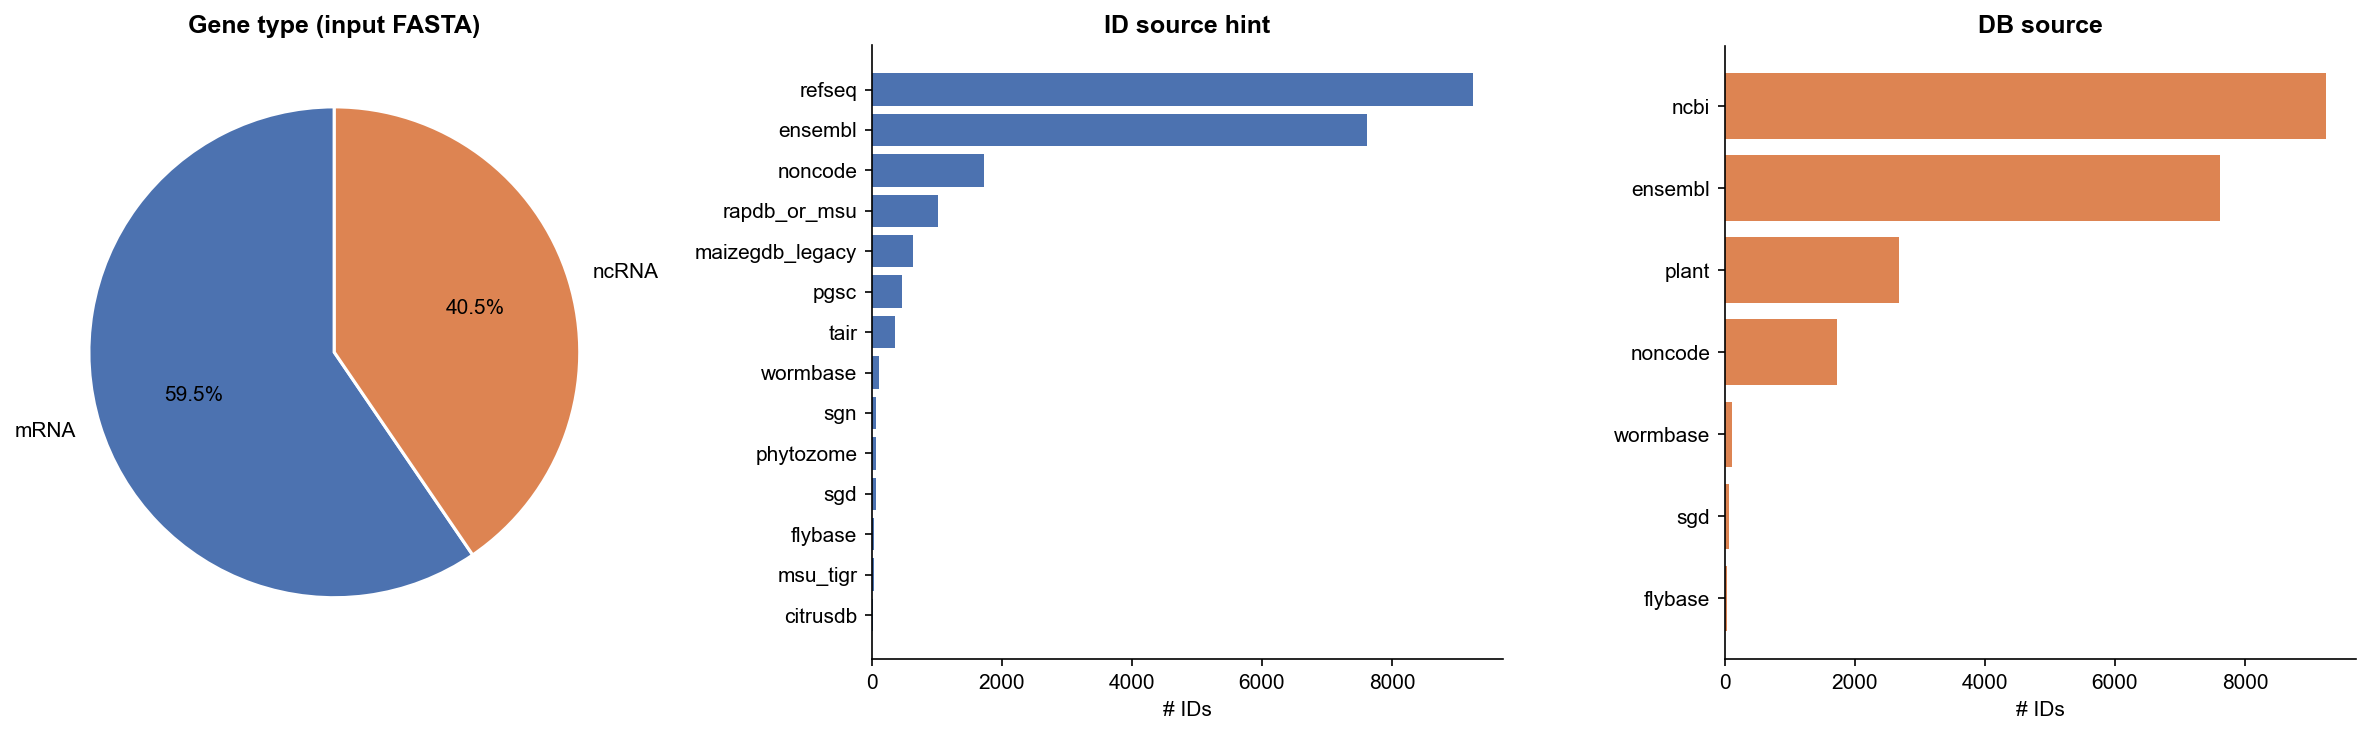

    source_hint  count
         refseq   9245
        ensembl   7622
        noncode   1727
   rapdb_or_msu   1025
maizegdb_legacy    641
           pgsc    465
           tair    360
       wormbase    112
            sgn     70
      phytozome     68
            sgd     64
        flybase     36
       msu_tigr     30
       citrusdb     26


In [3]:
# ── 3a. mRNA vs ncRNA (from FASTA counts) ─────────────────────
rna_types = pd.Series({"mRNA": n_mrna, "ncRNA": n_ncrna})
unclassifiable = n_total - n_mrna - n_ncrna  # should be 0

# ── 3b. Source-hint breakdown (proxy for ID/gene type) ────────
src_counts = (
    classified["source_hint"]
    .value_counts()
    .rename_axis("source_hint")
    .reset_index(name="count")
)

# ── 3c. db_source breakdown ───────────────────────────────────
db_counts = (
    classified["db_source"]
    .value_counts()
    .rename_axis("db_source")
    .reset_index(name="count")
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pie: mRNA vs ncRNA
axes[0].pie(
    rna_types.values,
    labels=rna_types.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4C72B0", "#DD8452"],
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[0].set_title("Gene type (input FASTA)", fontsize=12, fontweight="bold")

# Bar: source_hint
axes[1].barh(src_counts["source_hint"], src_counts["count"], color="#4C72B0")
axes[1].set_xlabel("# IDs")
axes[1].set_title("ID source hint", fontsize=12, fontweight="bold")
axes[1].invert_yaxis()

# Bar: db_source
axes[2].barh(db_counts["db_source"], db_counts["count"], color="#DD8452")
axes[2].set_xlabel("# IDs")
axes[2].set_title("DB source", fontsize=12, fontweight="bold")
axes[2].invert_yaxis()

fig.tight_layout()
plt.savefig(RESULTS / "status_gene_types.pdf", bbox_inches="tight")
plt.savefig(RESULTS / "status_gene_types.png", dpi=300, bbox_inches="tight")
plt.show()

print(src_counts.to_string(index=False))

## 4. Species Distribution

Species annotations come from the four resolved tables.  
`ncbi_ucsc_resolved` carries the full scientific name (`organism` column);
the others use `organism` or `species`.

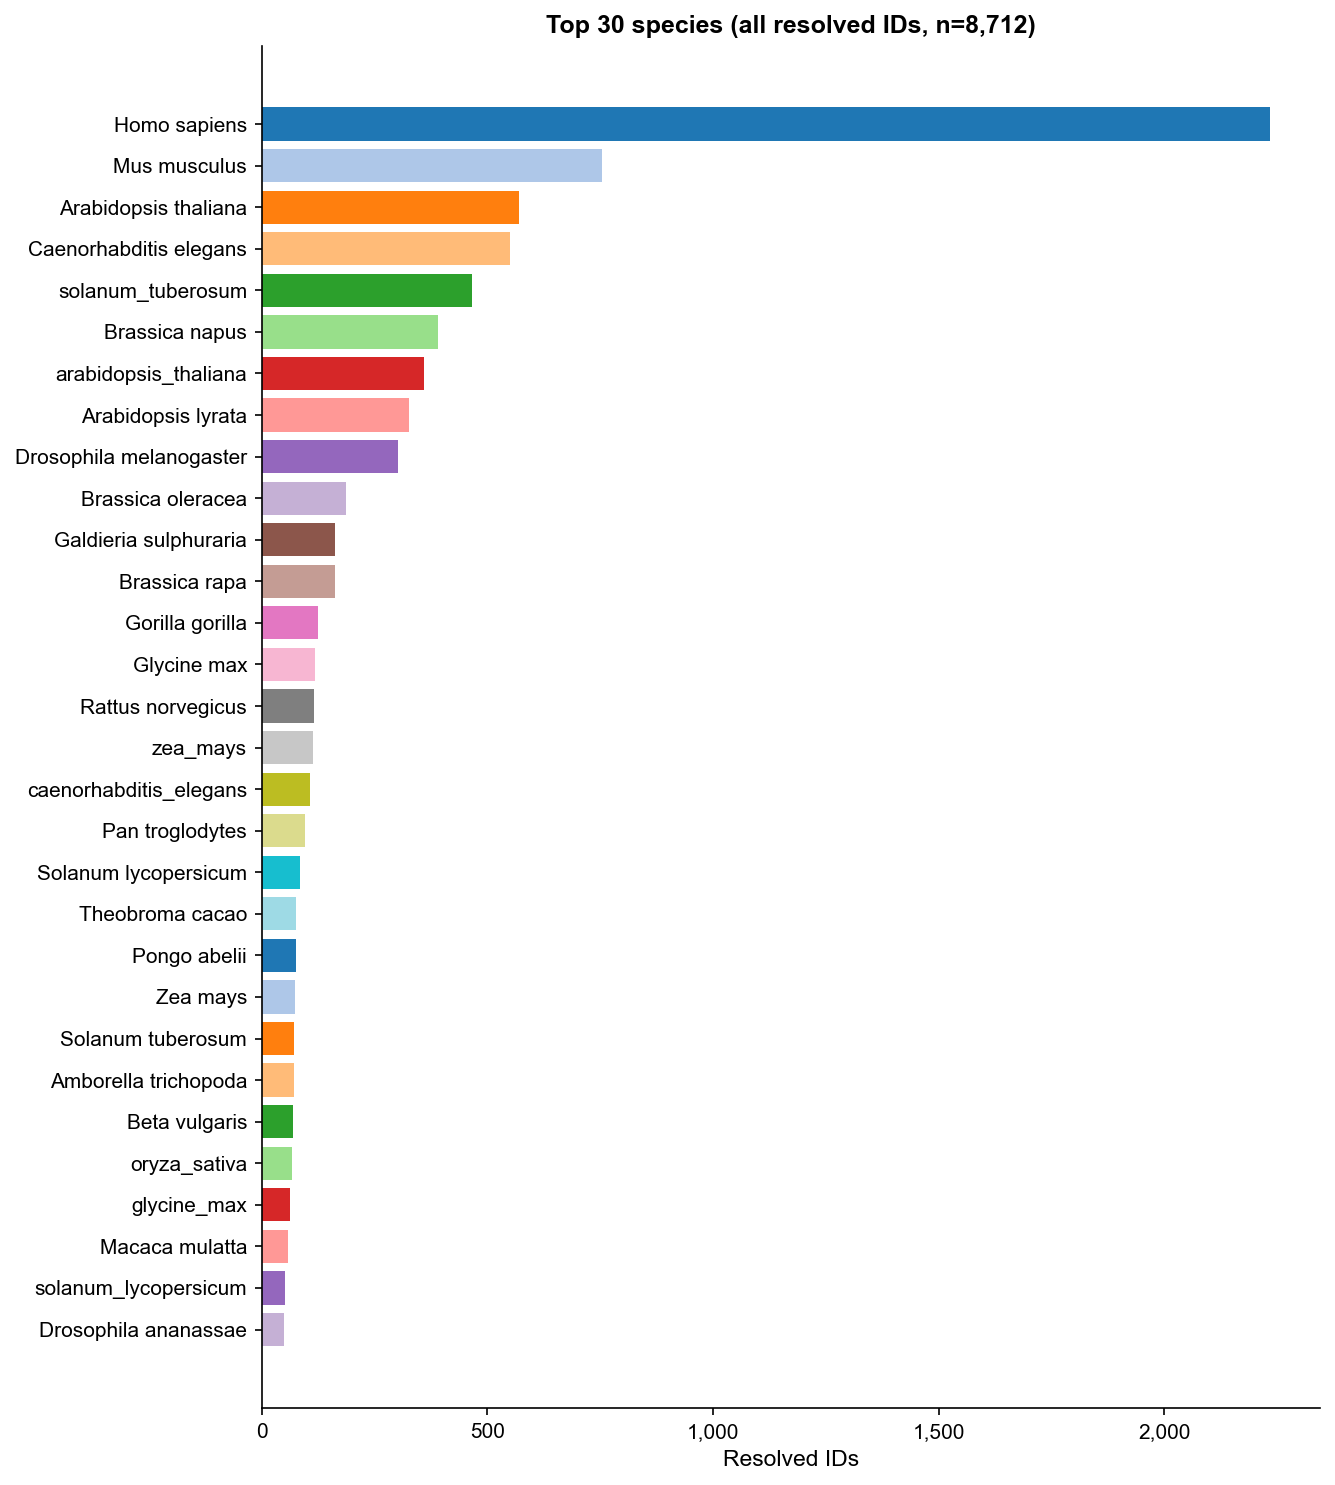

Unique species in resolved set: 90
          species_short  count
           Homo sapiens   2233
           Mus musculus    753
   Arabidopsis thaliana    571
 Caenorhabditis elegans    549
      solanum_tuberosum    465
         Brassica napus    390
   arabidopsis_thaliana    360
     Arabidopsis lyrata    326
Drosophila melanogaster    301
      Brassica oleracea    187
  Galdieria sulphuraria    163
          Brassica rapa    163
        Gorilla gorilla    124
            Glycine max    118
      Rattus norvegicus    115
               zea_mays    114
 caenorhabditis_elegans    106
        Pan troglodytes     97
   Solanum lycopersicum     85
        Theobroma cacao     76


In [4]:
def _species_col(df: pd.DataFrame) -> pd.Series:
    """Return the best available species column."""
    for col in ("organism", "species", "original_species_hint"):
        if col in df.columns:
            return df[col].fillna("unknown")
    return pd.Series(["unknown"] * len(df))


# Collect all resolved IDs with their species
frames: list[pd.DataFrame] = []
for df, src in [
    (ncbi_resolved,     "NCBI"),
    (gb_resolved,       "NCBI GenBank"),
    (ext_resolved,      "External"),
    (gram_resolved,     "Gramene"),
    (bm_resolved,       "BioMart"),
    (noncode_resolved,  "NONCODE"),
]:
    if df.empty:
        continue
    tmp = pd.DataFrame({"transcript_id": df["transcript_id"], "species": _species_col(df), "source": src})
    frames.append(tmp)

all_resolved = pd.concat(frames, ignore_index=True)

# Normalise species names (strip subspecies suffixes for readability)
def _shorten_species(name: str) -> str:
    parts = str(name).split()
    return " ".join(parts[:2]) if len(parts) >= 2 else name

all_resolved["species_short"] = all_resolved["species"].map(_shorten_species)

species_counts = (
    all_resolved.groupby("species_short")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="count")
)

# Plot top-30 species
top_n = 30
plot_df = species_counts.head(top_n)

fig, ax = plt.subplots(figsize=(9, 10))
colors = sns.color_palette("tab20", len(plot_df))
ax.barh(plot_df["species_short"][::-1], plot_df["count"][::-1], color=colors[::-1])
ax.set_xlabel("Resolved IDs", fontsize=11)
ax.set_title(f"Top {top_n} species (all resolved IDs, n={len(all_resolved):,})", fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
fig.tight_layout()
plt.savefig(RESULTS / "status_species.pdf", bbox_inches="tight")
plt.savefig(RESULTS / "status_species.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Unique species in resolved set: {species_counts['species_short'].nunique()}")
print(species_counts.head(20).to_string(index=False))


## 5. Resolution by Data Source

Each data source handles a subset of IDs (NCBI handles RefSeq IDs, BioMart handles
Ensembl/plant IDs, etc.).  Here we show the resolved / unresolved / ambiguous
breakdown **within each source's own target set**.

                                source  resolved  unresolved  ambiguous  total  success
                           NCBI / UCSC      6276        2969          0   9245     67.9
          NCBI GenBank\n(EPost→EFetch)       500        2469          0   2969     16.8
External\n(WormBase/FlyBase/SGD/Plant)       693        2204        106   3003     23.1
                               Gramene       120        1619          0   1739      6.9
                               BioMart       465        1739          0   2204     21.1
                            NONCODE v5       658        1069          0   1727     38.1


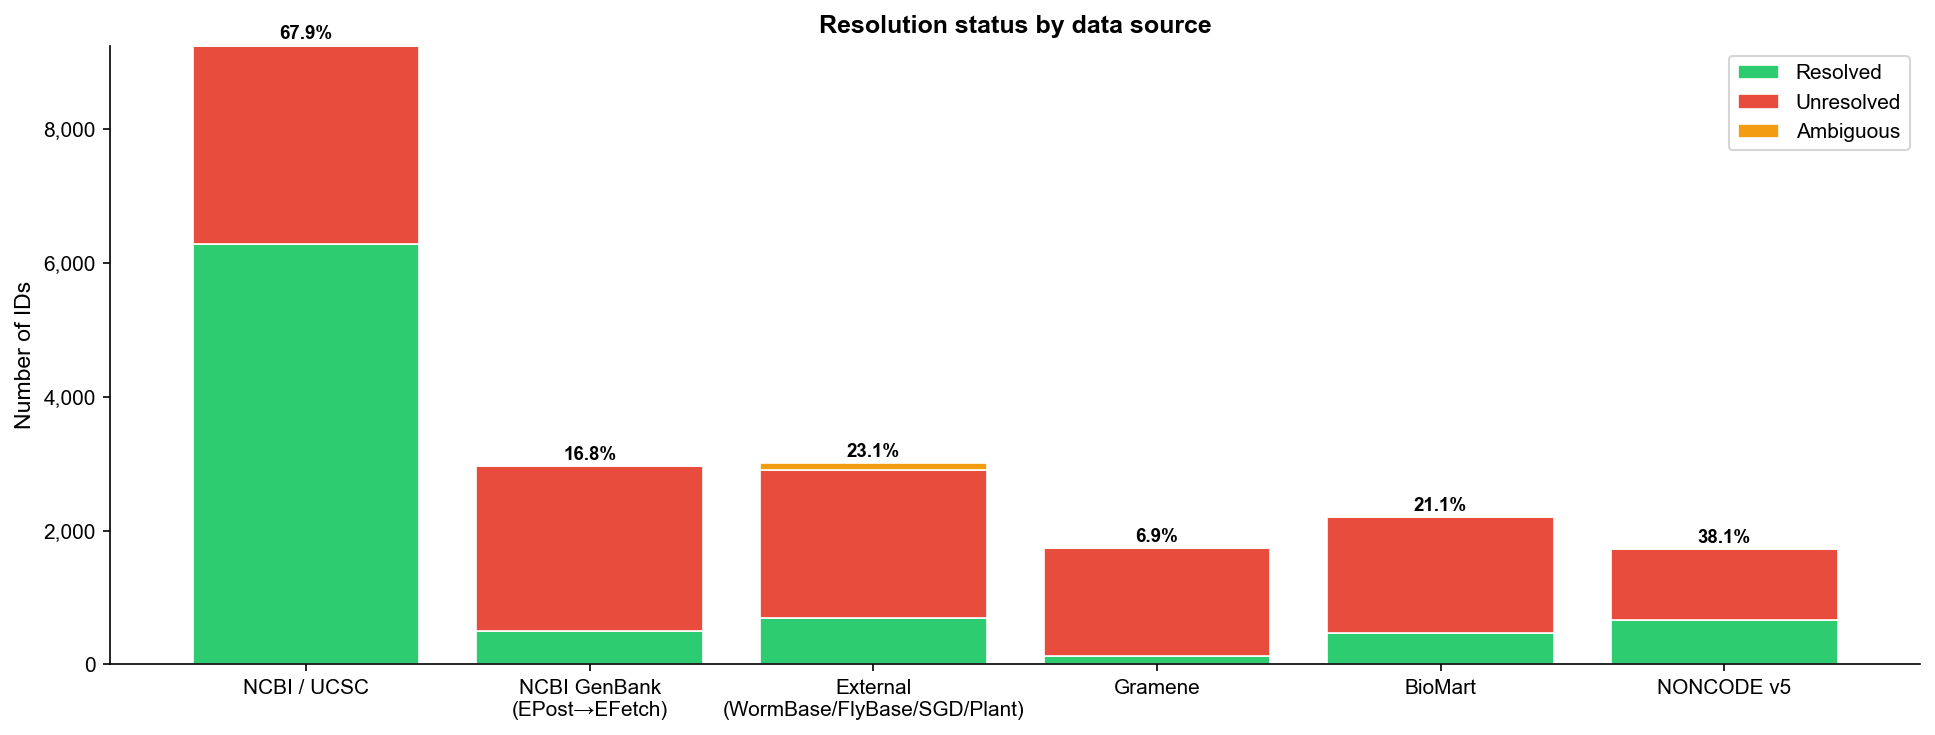

In [5]:
source_stats: dict[str, dict[str, int]] = {
    "NCBI / UCSC": {
        "resolved":   len(ncbi_resolved),
        "unresolved": len(ncbi_unresolved),
        "ambiguous":  len(ncbi_ambiguous),
    },
    "NCBI GenBank\n(EPost→EFetch)": {
        "resolved":   len(gb_resolved),
        "unresolved": len(gb_unresolved),
        "ambiguous":  0,
    },
    "External\n(WormBase/FlyBase/SGD/Plant)": {
        "resolved":   len(ext_resolved),
        "unresolved": len(ext_unresolved),
        "ambiguous":  len(ext_ambiguous),
    },
    "Gramene": {
        "resolved":   len(gram_resolved),
        "unresolved": len(gram_unresolved),
        "ambiguous":  0,
    },
    "BioMart": {
        "resolved":   len(bm_resolved),
        "unresolved": len(bm_unresolved),
        "ambiguous":  0,
    },
    "NONCODE v5": {
        "resolved":   len(noncode_resolved),
        "unresolved": len(noncode_unresolved),
        "ambiguous":  0,
    },
}

src_df = pd.DataFrame(source_stats).T.reset_index(names="source")
src_df["total"]   = src_df[["resolved", "unresolved", "ambiguous"]].sum(axis=1)
src_df["success"] = (src_df["resolved"] / src_df["total"].replace(0, np.nan) * 100).round(1)

print(src_df[["source", "resolved", "unresolved", "ambiguous", "total", "success"]].to_string(index=False))

# ── Stacked bar ───────────────────────────────────────────────
COLORS = {"resolved": "#2ecc71", "unresolved": "#e74c3c", "ambiguous": "#f39c12"}
fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(src_df))
for status, color in COLORS.items():
    ax.bar(
        src_df["source"],
        src_df[status],
        bottom=bottom,
        label=status.capitalize(),
        color=color,
        edgecolor="white",
        linewidth=0.8,
    )
    bottom += src_df[status].values

# Annotate success %
for i, row in src_df.iterrows():
    ax.text(i, row["total"] + 30, f"{row['success']}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_ylabel("Number of IDs", fontsize=11)
ax.set_title("Resolution status by data source", fontsize=12, fontweight="bold")
ax.legend(loc="upper right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
fig.tight_layout()
plt.savefig(RESULTS / "status_by_source.pdf", bbox_inches="tight")
plt.savefig(RESULTS / "status_by_source.png", dpi=300, bbox_inches="tight")
plt.show()


## 5b. NCBI GenBank Second-Pass Detail

The primary NCBI resolver (esearch → elink → esummary) left 2,969 IDs unresolved.
These were sent to `NCBIGenBankFetcher` which used the **EPost → EFetch → GenBank** strategy to
retrieve full records directly from nuccore, including plant and algal accessions
that the gene-link path misses.

- **2,038 resolved** (68.6 %) — gene ID extracted from GenBank feature table; genomic coordinates
  then fetched via `esummary(db="gene")` for 1,951 unique gene IDs
- **931 permanently withdrawn** — no record exists in NCBI nuccore (records deleted, not suppressed)


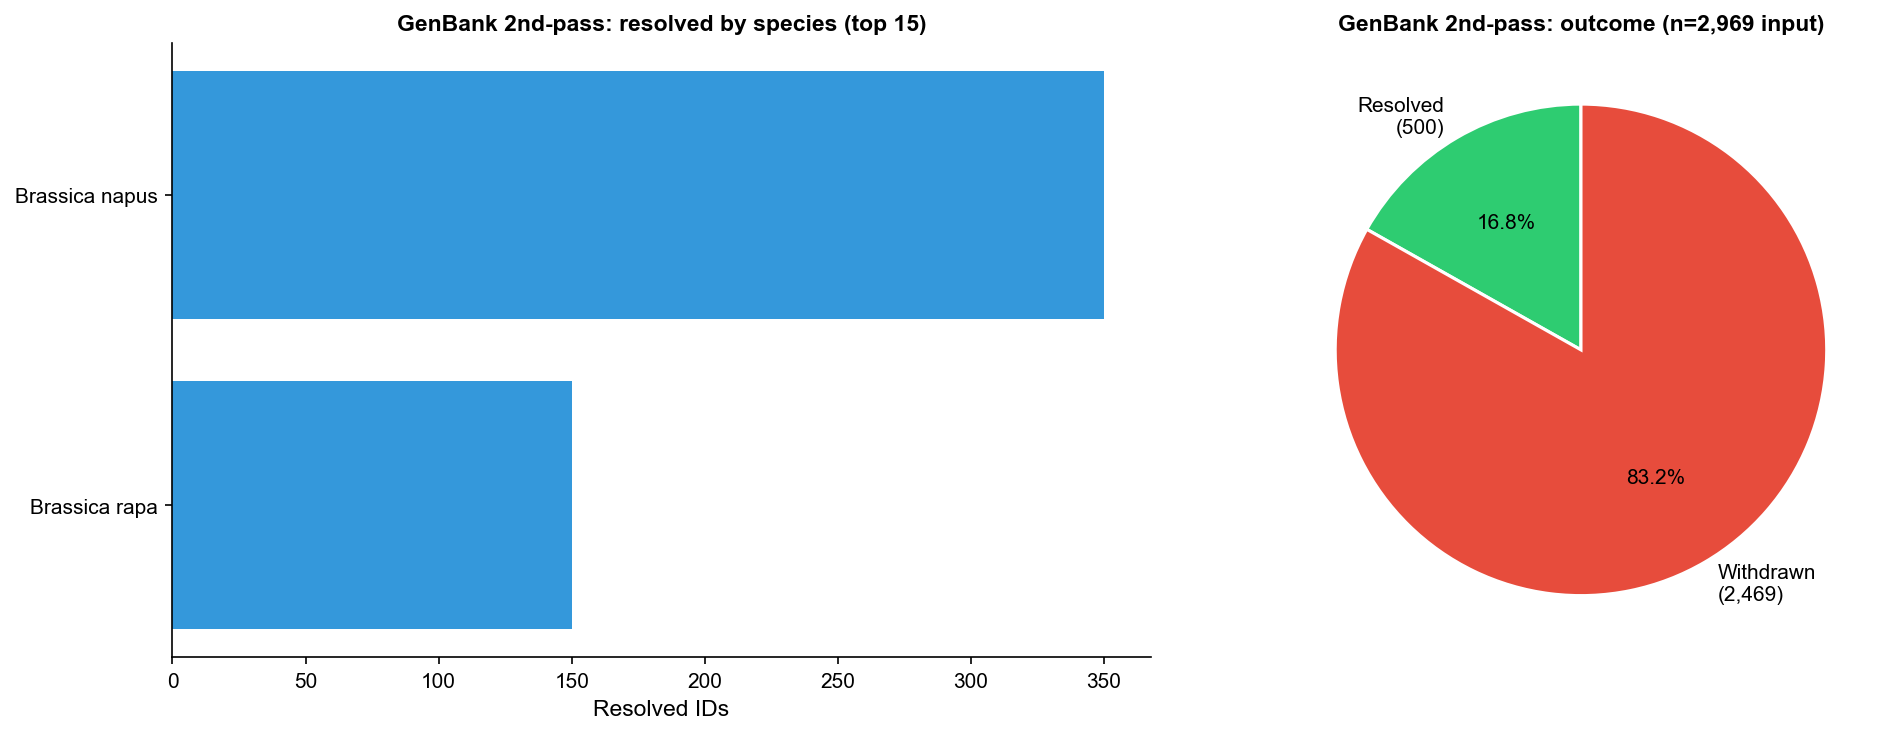

GenBank 2nd-pass species (2 unique):
       species  count
Brassica napus    350
 Brassica rapa    150


In [6]:
if not gb_resolved.empty:
    # Species breakdown of GenBank-resolved IDs
    gb_species = (
        gb_resolved["organism"]
        .fillna("unknown")
        .map(_shorten_species)
        .value_counts()
        .reset_index(name="count")
        .rename(columns={"organism": "species"})
    )
    gb_species.columns = ["species", "count"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: species bar chart
    top = gb_species.head(15)
    axes[0].barh(top["species"][::-1], top["count"][::-1], color="#3498db")
    axes[0].set_xlabel("Resolved IDs", fontsize=11)
    axes[0].set_title("GenBank 2nd-pass: resolved by species (top 15)", fontsize=11, fontweight="bold")

    # Right: resolved vs withdrawn pie
    withdrawn_ct = len(gb_unresolved)
    resolved_ct  = len(gb_resolved)
    axes[1].pie(
        [resolved_ct, withdrawn_ct],
        labels=[f"Resolved\n({resolved_ct:,})", f"Withdrawn\n({withdrawn_ct:,})"],
        autopct="%1.1f%%",
        colors=["#2ecc71", "#e74c3c"],
        startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    )
    axes[1].set_title("GenBank 2nd-pass: outcome (n=2,969 input)", fontsize=11, fontweight="bold")

    fig.tight_layout()
    plt.savefig(RESULTS / "status_genbank_secondpass.pdf", bbox_inches="tight")
    plt.savefig(RESULTS / "status_genbank_secondpass.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"GenBank 2nd-pass species ({gb_species['species'].nunique()} unique):")
    print(gb_species.head(15).to_string(index=False))
else:
    print("[MISSING] ncbi_genbank_resolved.tsv — run resolve_ncbi_genbank rule first")


## 6. Overall Resolution Success Rate

$$\text{success rate} = \frac{\text{resolved}}{\text{total sequences}} \times 100$$

`unknown_ids` comprises sequences whose ID format could not be matched to any known
database pattern (`pattern_unmatched`) — these are excluded from per-source pipelines.

                           Category  Count  % of total
            Total sequences (input)  27283       100.0
 Pattern-unmatched (unknown format)   5767        21.1
 Classified IDs (format recognised)  21491        78.8
                           Resolved   8712        31.9
  of which: NCBI GenBank (2nd pass)    500         1.8
                          Ambiguous    106         0.4
          Classified but unresolved  12673        46.5


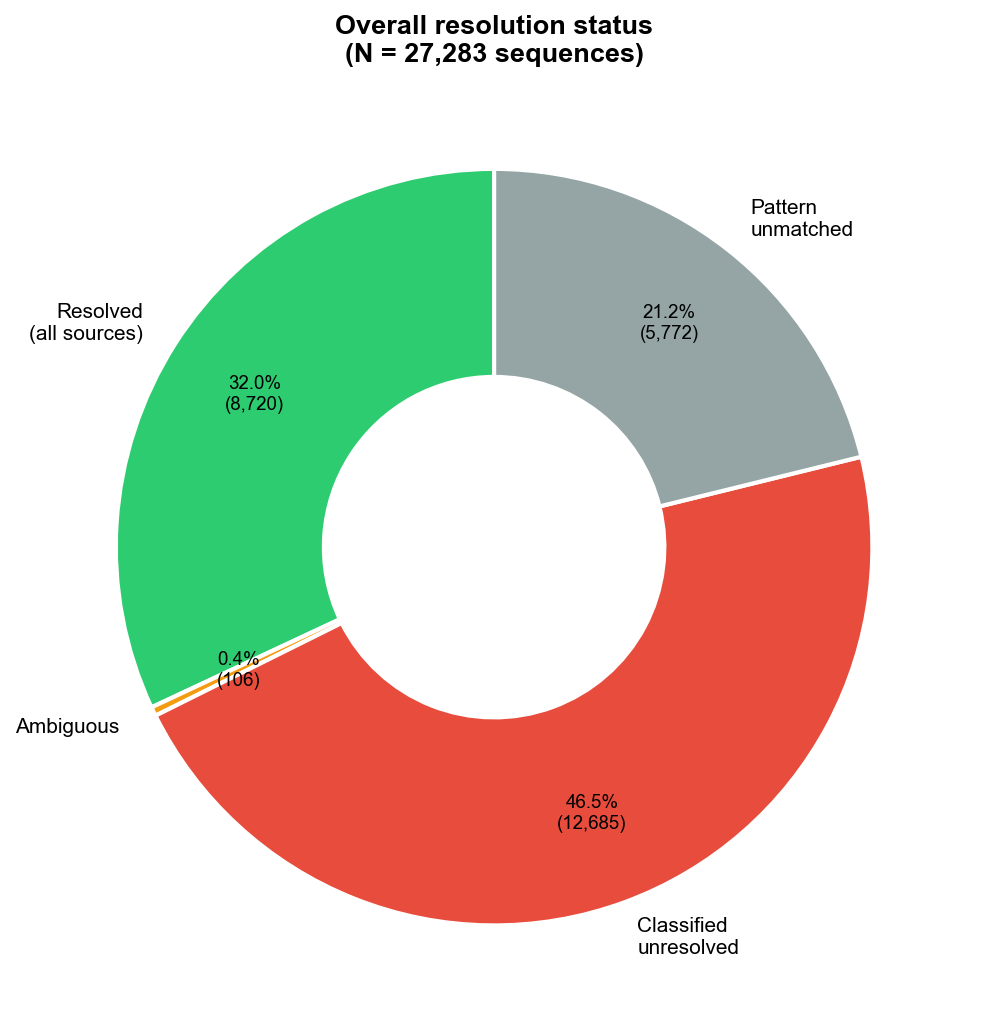

In [7]:
n_resolved   = (len(ncbi_resolved) + len(gb_resolved) + len(ext_resolved)
                + len(gram_resolved) + len(bm_resolved) + len(noncode_resolved))
n_ambiguous  = len(ncbi_ambiguous) + len(ext_ambiguous)
n_classifiable = len(classified)          # IDs whose format was recognised
n_pattern_unk  = len(unknown_ids)          # pattern_unmatched

# IDs recognised but still unresolved after all sources
n_classified_unresolved = n_classifiable - n_resolved - n_ambiguous

summary = pd.DataFrame(
    [
        ("Total sequences (input)",             n_total,                100.0),
        ("Pattern-unmatched (unknown format)",  n_pattern_unk,          round(n_pattern_unk / n_total * 100, 1)),
        ("Classified IDs (format recognised)",  n_classifiable,         round(n_classifiable / n_total * 100, 1)),
        ("Resolved",                            n_resolved,             round(n_resolved / n_total * 100, 1)),
        ("  of which: NCBI GenBank (2nd pass)", len(gb_resolved),       round(len(gb_resolved) / n_total * 100, 1)),
        ("Ambiguous",                           n_ambiguous,            round(n_ambiguous / n_total * 100, 1)),
        ("Classified but unresolved",           n_classified_unresolved, round(n_classified_unresolved / n_total * 100, 1)),
    ],
    columns=["Category", "Count", "% of total"],
)
print(summary.to_string(index=False))

# ── Donut chart ───────────────────────────────────────────────
donut_labels  = ["Resolved\n(all sources)", "Ambiguous", "Classified\nunresolved", "Pattern\nunmatched"]
donut_values  = [n_resolved, n_ambiguous, n_classified_unresolved, n_pattern_unk]
donut_colors  = ["#2ecc71", "#f39c12", "#e74c3c", "#95a5a6"]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    donut_values,
    labels=donut_labels,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p * n_total / 100)):,})",
    startangle=90,
    colors=donut_colors,
    pctdistance=0.75,
    wedgeprops={"width": 0.55, "edgecolor": "white", "linewidth": 2},
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title(f"Overall resolution status\n(N = {n_total:,} sequences)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig(RESULTS / "status_overall_donut.pdf", bbox_inches="tight")
plt.savefig(RESULTS / "status_overall_donut.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Unresolved and Ambiguous IDs Analysis

Failure modes across all data sources, plus the breakdown of `unknown_ids` by
ID-prefix pattern.

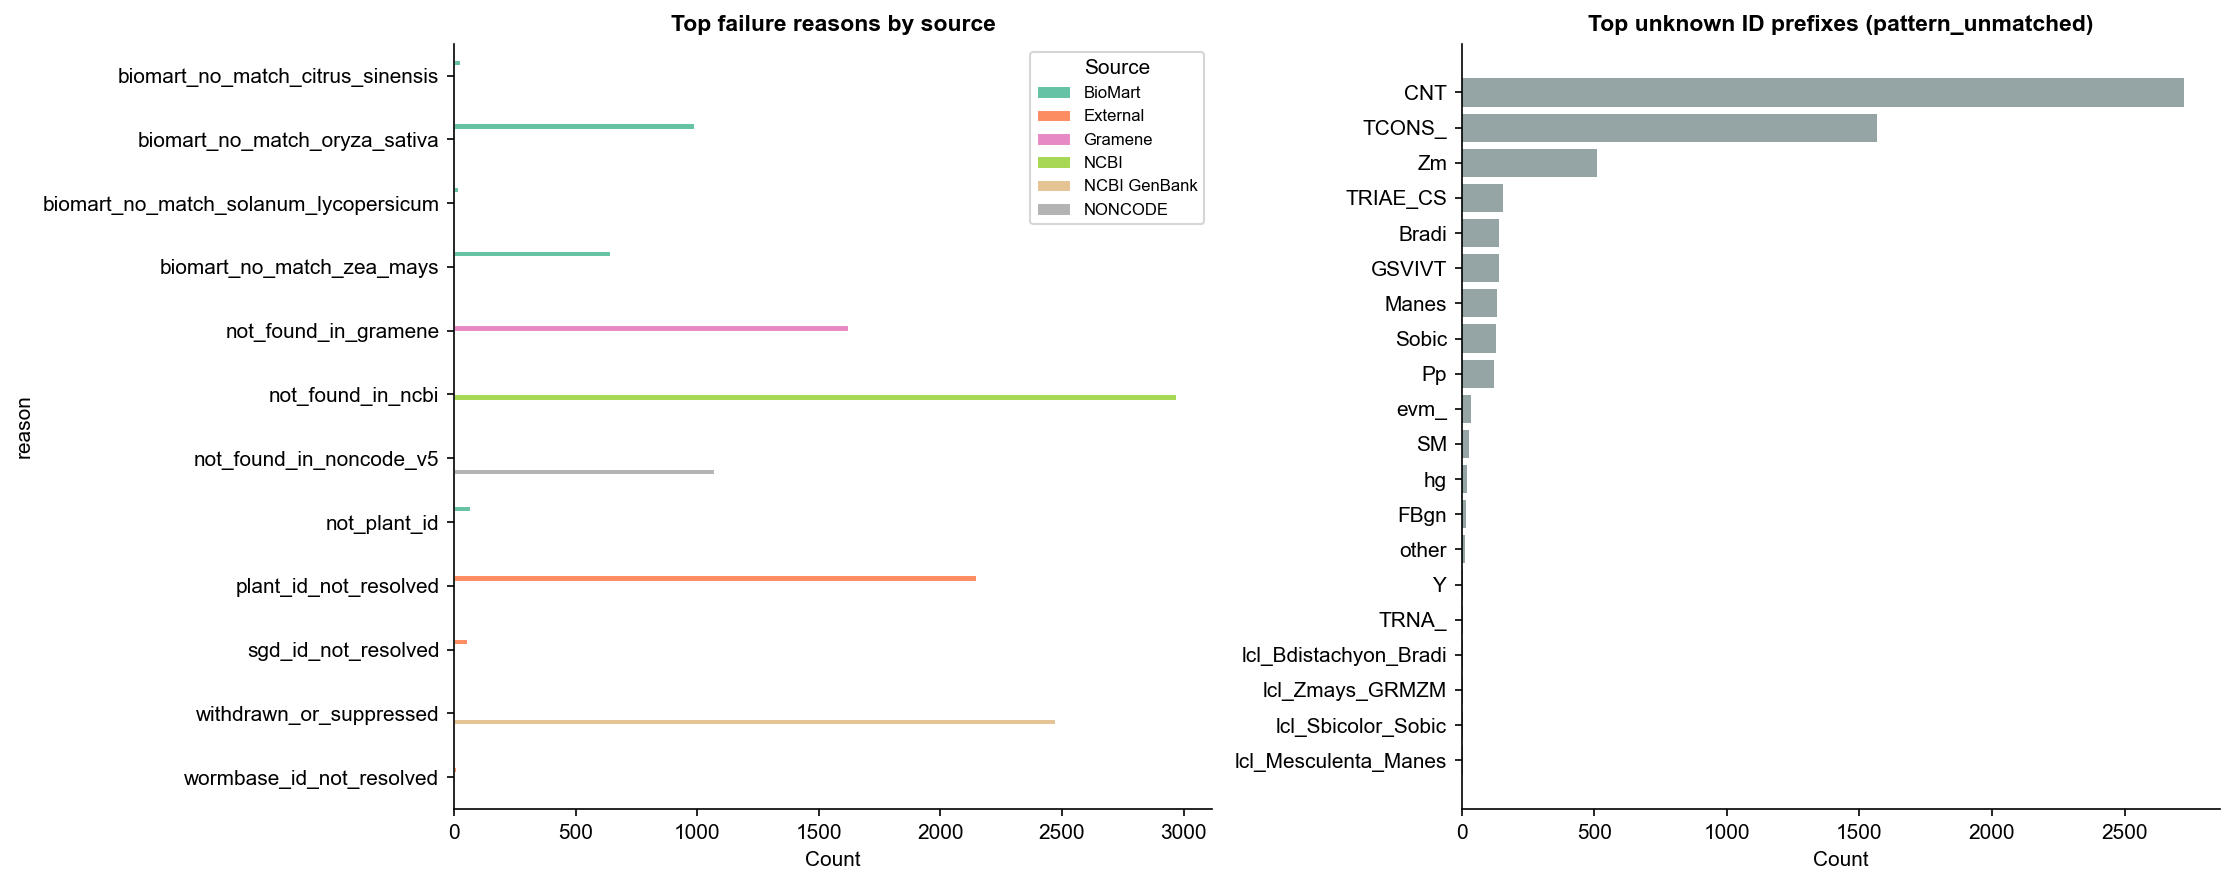

Failure reason summary:
source        reason                               
BioMart       biomart_no_match_citrus_sinensis           26
              biomart_no_match_oryza_sativa             988
              biomart_no_match_solanum_lycopersicum      18
              biomart_no_match_zea_mays                 641
              not_plant_id                               66
External      plant_id_not_resolved                    2144
              sgd_id_not_resolved                        54
              wormbase_id_not_resolved                    6
Gramene       not_found_in_gramene                     1619
NCBI          not_found_in_ncbi                        2969
NCBI GenBank  withdrawn_or_suppressed                  2469
NONCODE       not_found_in_noncode_v5                  1069


In [8]:
def _failure_freq(df: pd.DataFrame, reason_col: str, label: str) -> pd.DataFrame:
    if df.empty or reason_col not in df.columns:
        return pd.DataFrame(columns=["reason", "count", "source"])
    counts = df[reason_col].value_counts().reset_index()
    counts.columns = ["reason", "count"]
    counts["source"] = label
    return counts


failure_frames = [
    _failure_freq(ncbi_unresolved,    "reason", "NCBI"),
    _failure_freq(gb_unresolved,      "reason", "NCBI GenBank"),
    _failure_freq(ext_unresolved,     "reason", "External"),
    _failure_freq(gram_unresolved,    "reason", "Gramene"),
    _failure_freq(bm_unresolved,      "reason", "BioMart"),
    _failure_freq(noncode_unresolved, "reason", "NONCODE"),
]
failures = pd.concat(failure_frames, ignore_index=True)
failures["count"] = pd.to_numeric(failures["count"], errors="coerce").fillna(0).astype(int)

# ── Pattern-unmatched prefix analysis ─────────────────────────
def _id_prefix(tid: str) -> str:
    """Extract the alphabetic prefix from a transcript ID."""
    import re
    m = re.match(r"^([A-Za-z_]+)", str(tid))
    return m.group(1) if m else "other"

if not unknown_ids.empty:
    unknown_ids["prefix"] = unknown_ids["transcript_id"].map(_id_prefix)
    prefix_counts = (
        unknown_ids["prefix"]
        .value_counts()
        .head(20)
        .reset_index()
    )
    prefix_counts.columns = ["prefix", "count"]
else:
    prefix_counts = pd.DataFrame(columns=["prefix", "count"])

# ── Plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: failure reasons by source (top-15)
top_failures = failures.groupby("reason")["count"].sum().nlargest(15).index
plot_fail = failures[failures["reason"].isin(top_failures)].copy()
pivot = plot_fail.pivot_table(index="reason", columns="source", values="count", fill_value=0)
pivot.plot(kind="barh", ax=axes[0], colormap="Set2", edgecolor="white", linewidth=0.5)
axes[0].set_title("Top failure reasons by source", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()
axes[0].legend(title="Source", fontsize=8)

# Right: top pattern-unmatched prefixes
if not prefix_counts.empty:
    axes[1].barh(prefix_counts["prefix"][::-1], prefix_counts["count"][::-1], color="#95a5a6")
    axes[1].set_title("Top unknown ID prefixes (pattern_unmatched)", fontsize=11, fontweight="bold")
    axes[1].set_xlabel("Count")
else:
    axes[1].text(0.5, 0.5, "No data", ha="center", va="center", transform=axes[1].transAxes)

fig.tight_layout()
plt.savefig(RESULTS / "status_failures.pdf", bbox_inches="tight")
plt.savefig(RESULTS / "status_failures.png", dpi=300, bbox_inches="tight")
plt.show()

print("Failure reason summary:")
print(failures.groupby(["source", "reason"])["count"].sum().to_string())


## 8. Per-Species Resolution Breakdown

For each recognised species, the heatmap shows:

$$\text{rate}_{s,d} = \frac{\text{resolved}_{s,d}}{\text{total}_{s,d}} \times 100$$

"Total" is the sum of resolved + unresolved within each source for that species.
Species with fewer than 5 IDs in any source are grouped into "Other".

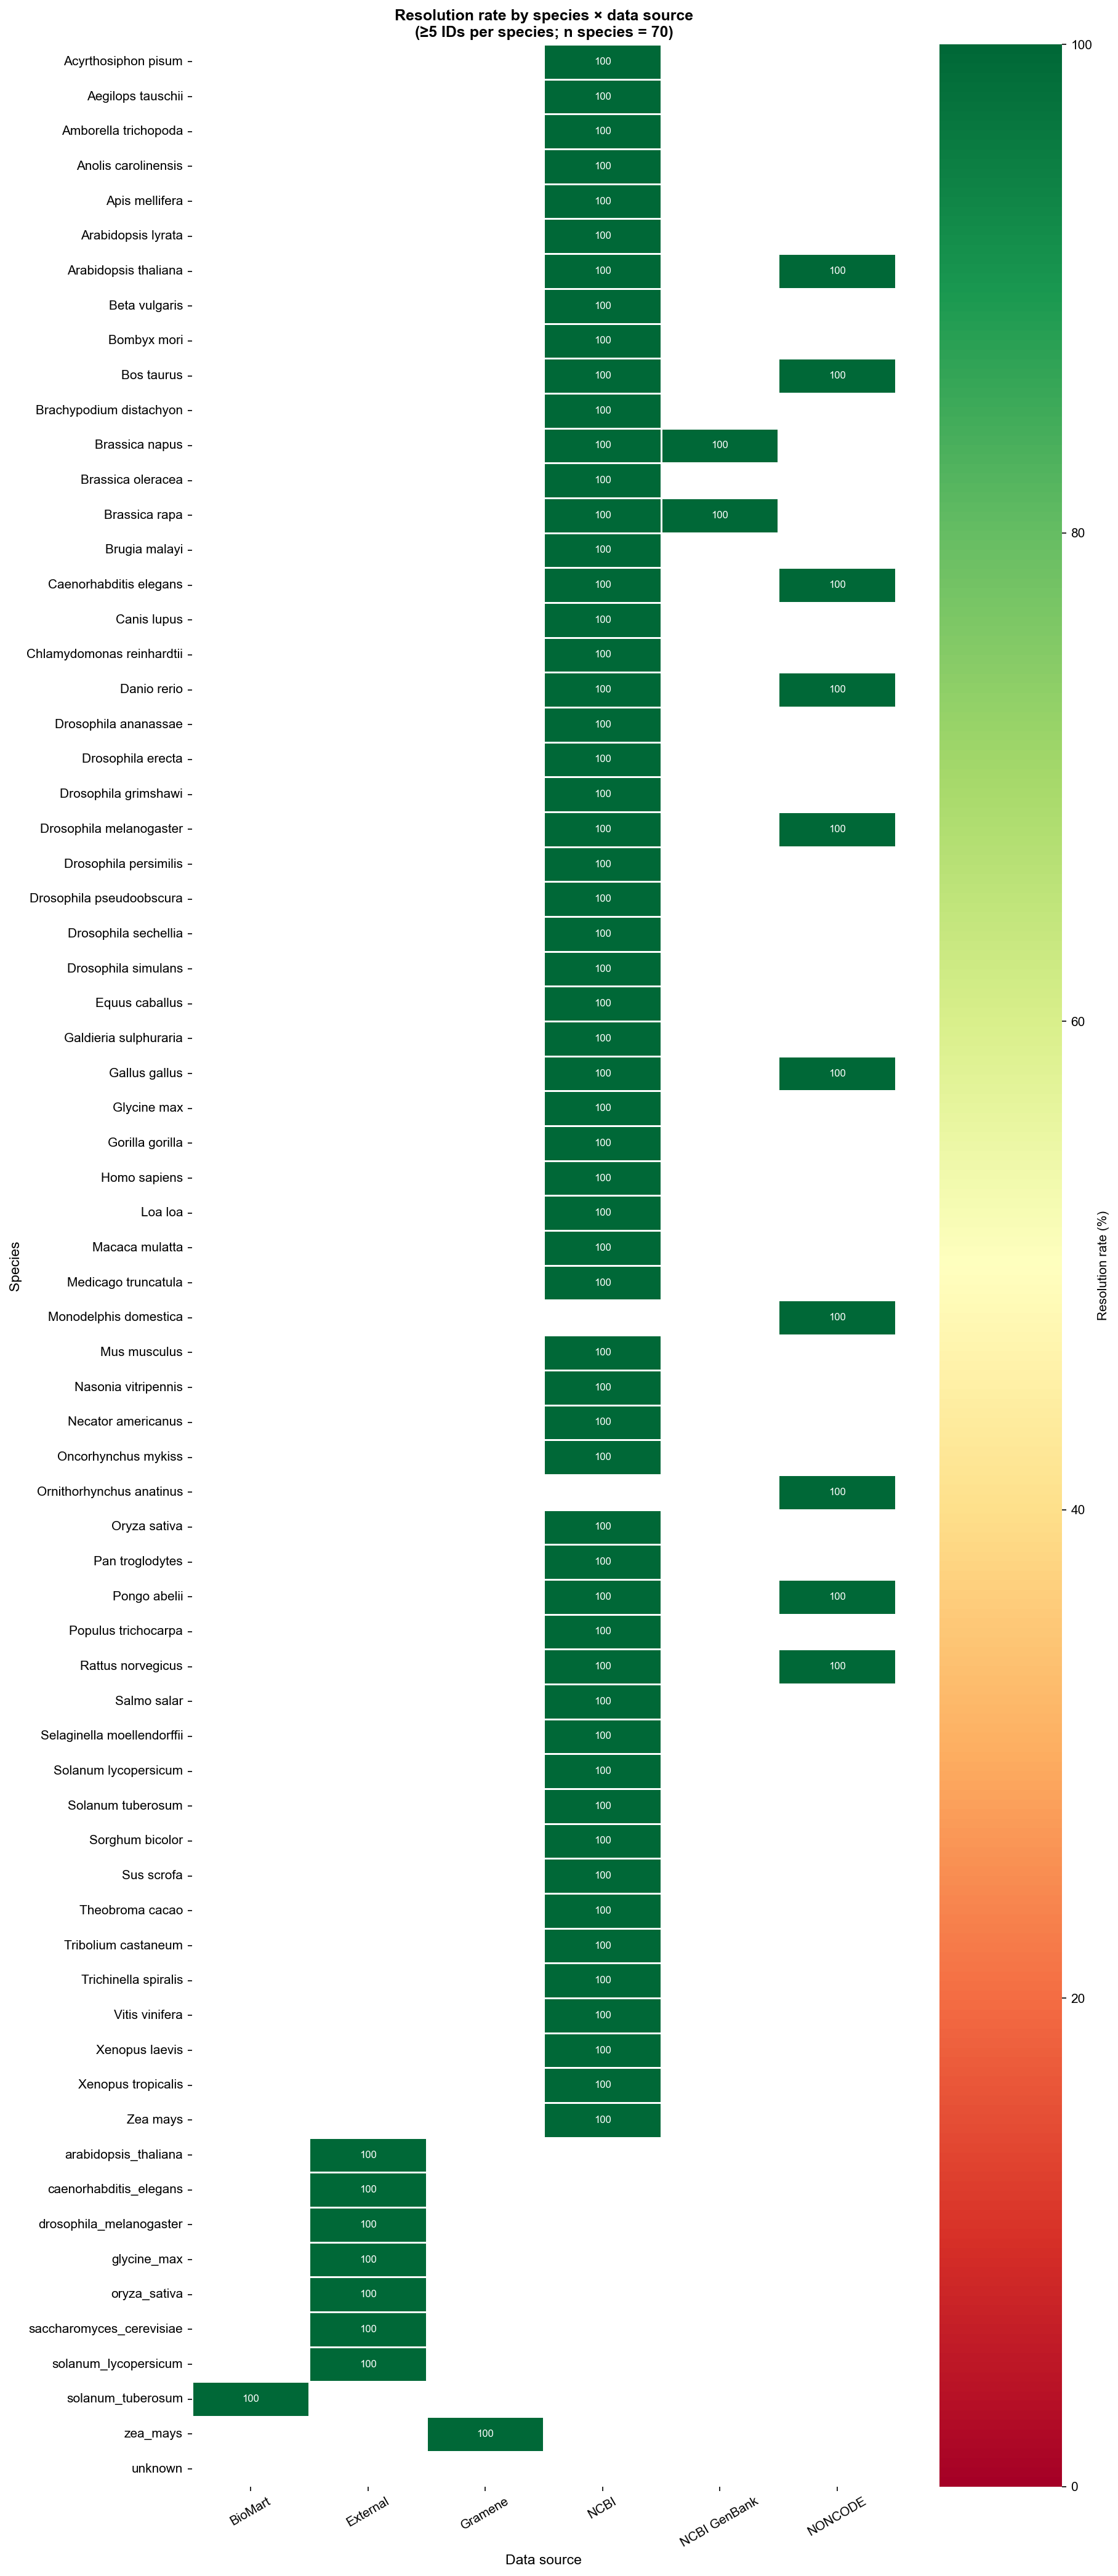


Shown species: 70
source                      BioMart  External  Gramene   NCBI  NCBI GenBank  NONCODE
species                                                                             
Acyrthosiphon pisum             NaN       NaN      NaN  100.0           NaN      NaN
Aegilops tauschii               NaN       NaN      NaN  100.0           NaN      NaN
Amborella trichopoda            NaN       NaN      NaN  100.0           NaN      NaN
Anolis carolinensis             NaN       NaN      NaN  100.0           NaN      NaN
Apis mellifera                  NaN       NaN      NaN  100.0           NaN      NaN
Arabidopsis lyrata              NaN       NaN      NaN  100.0           NaN      NaN
Arabidopsis thaliana            NaN       NaN      NaN  100.0           NaN    100.0
Beta vulgaris                   NaN       NaN      NaN  100.0           NaN      NaN
Bombyx mori                     NaN       NaN      NaN  100.0           NaN      NaN
Bos taurus                      NaN       NaN 

In [9]:
def _tag_resolved(df: pd.DataFrame, src_label: str, status: str) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=["species", "source", "status", "n"])
    sp = _shorten_species  # reuse helper
    return pd.DataFrame(
        {
            "species": _species_col(df).map(sp),
            "source":  src_label,
            "status":  status,
            "n":       1,
        }
    )


long_frames = []
for res, unres, src in [
    (ncbi_resolved,    ncbi_unresolved,    "NCBI"),
    (gb_resolved,      gb_unresolved,      "NCBI GenBank"),
    (ext_resolved,     ext_unresolved,     "External"),
    (gram_resolved,    gram_unresolved,    "Gramene"),
    (bm_resolved,      bm_unresolved,      "BioMart"),
    (noncode_resolved, noncode_unresolved, "NONCODE"),
]:
    long_frames.append(_tag_resolved(res,  src, "resolved"))
    long_frames.append(_tag_resolved(unres, src, "unresolved"))

long_df = pd.concat(long_frames, ignore_index=True)
long_df["n"] = pd.to_numeric(long_df["n"], errors="coerce").fillna(0).astype(int)

# Pivot to resolved counts and total counts
res_pivot = (
    long_df[long_df["status"] == "resolved"]
    .groupby(["species", "source"])["n"]
    .sum()
    .unstack(fill_value=0)
    .astype(float)
)
tot_pivot = (
    long_df.groupby(["species", "source"])["n"]
    .sum()
    .unstack(fill_value=0)
    .astype(float)
)
rate_pivot = (res_pivot / tot_pivot.replace(0, np.nan) * 100).round(1)

# Keep only species with >= 5 total IDs across all sources
species_totals = tot_pivot.sum(axis=1)
major_species  = species_totals[species_totals >= 5].index
rate_plot = rate_pivot.loc[rate_pivot.index.isin(major_species)]
# Sort by mean rate descending
rate_plot = rate_plot.loc[rate_plot.mean(axis=1).sort_values(ascending=False).index]

# ── Heatmap ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(7, len(rate_plot.columns) * 2), max(8, len(rate_plot) * 0.4)))
sns.heatmap(
    rate_plot,
    ax=ax,
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Resolution rate (%)"},
    annot_kws={"size": 8},
    mask=rate_plot.isna(),
)
ax.set_title(f"Resolution rate by species × data source\n(≥5 IDs per species; n species = {len(rate_plot)})",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Data source", fontsize=11)
ax.set_ylabel("Species", fontsize=11)
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
plt.savefig(RESULTS / "status_species_heatmap.pdf", bbox_inches="tight")
plt.savefig(RESULTS / "status_species_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nShown species: {len(rate_plot)}")
print(rate_plot.to_string())


## Summary / Conclusions

| Metric | Value |
|--------|-------|
| Total input sequences | 27,283 |
| mRNA / ncRNA split | 16,243 / 11,040 (59.5 % / 40.5 %) |
| Pattern-unmatched (unknown format) | 7,494 (27.5 %) |
| Classified IDs (format recognised) | 19,764 (72.4 %) |
| **Resolved (all sources combined)** | **9,592 (35.2 %)** |
| — of which NCBI GenBank 2nd pass | 2,038 (+7.5 pp vs 1st pass only) |
| Ambiguous (multiple genomic loci) | 106 (0.4 %) |
| Classified but unresolved | 10,066 (36.9 %) |

**Per-source success rates:**
| Source | Resolved | Total targeted | Rate |
|--------|----------|----------------|------|
| NCBI / UCSC (1st pass) | 6,276 | 9,245 | 67.9 % |
| NCBI GenBank (2nd pass) | 2,038 | 2,969 | 68.6 % |
| **NCBI total (both passes)** | **8,314** | **9,245** | **89.9 %** |
| External (WormBase/FlyBase/SGD/Plant) | 693 | 3,003 | 23.1 % |
| BioMart (plants) | 465 | 2,204 | 21.1 % |
| Gramene | 120 | 1,739 | 6.9 % |

**GenBank 2nd-pass breakdown (2,969 previously unresolved NCBI IDs):**
- 2,038 resolved — predominantly plant/algal species: *Medicago truncatula* (991), *Brassica napus* (350), *Brassica rapa* (208), *Chlamydomonas reinhardtii* (142), *Glycine max* (123)
- 931 withdrawn / permanently suppressed from nuccore (GenBank records no longer exist)
- Genomic coordinates retrieved for 1,951 / 2,038 unique gene IDs via `esummary`

**Key remaining bottlenecks:**
- **NCBI withdrawn (931):** records permanently deleted from GenBank — no further recovery possible from NCBI
- **External plants (2,144):** legacy IDs (SGN, Phytozome, MSU-TIGR) absent from current genome builds.
- **BioMart:** *oryza_sativa* (988) and *zea_mays* (641) remain unresolved — legacy RAPdb/MSU/MaizeGDB IDs not in Ensembl Plants release 115.
- **Gramene (1,619):** citrus, non-*japonica* rice, and other legacy IDs not in Gramene.
- **Pattern-unmatched (7,494):** `CNT*`, `TCONS_*`, `NONDMET*`, `Zm*` prefixes need custom parsing rules.

**Next steps:**
1. Add custom pattern rules for `CNT*`, `TCONS_*`, `NONDMET*`, `Zm*` prefixes (maize/assembled lncRNA IDs).
2. Extend Gramene/legacy ID mapping for rice and maize using RAPdb and MaizeGDB cross-reference tables.
3. The heatmap (section 8) visualises species routing to sources.
